#### Requirements and preamble

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

## add a path to the rice package to the sys.path
import sys
sys.path.append("../../rice")

import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
## Plotting settings (skip these cells if you are running this notebook in a different environment)
import degas as dg
## Set helvetica font
plt.rcParams.update({'font.family': 'Helvetica'})
## Get a consistent color map
import seaborn as sns
cmap_mako = sns.color_palette("mako", as_cmap=True)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Analyze EMT dataset

+ Preprocessing based on:
https://github.com/cliffzhou92/MuTrans-release/blob/main/Example/example-emt-raw.ipynb

### Run the nonlinearity scoring on an example dynamical system

This block requires the installation of the `dysts` package, 

```bash
    uv install dysts
```

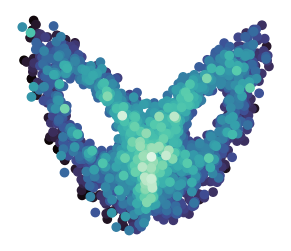

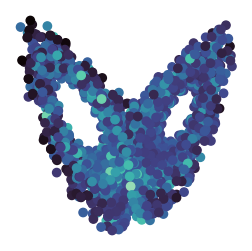

In [7]:
from dysts.flows import Lorenz

eq = Lorenz()
sol = eq.make_trajectory(2000, pts_per_period=30)
sigma_lorenz = calculate_sigma(sol)
sigma_lorenz_multivariate = calculate_sigma(sol, channelwise=False)

plt.figure(figsize=(3.5, 3))
plot_order = np.argsort(np.log(1/np.mean(sigma_lorenz,axis=0)))
plt.scatter(sol[plot_order, 0], sol[plot_order, 2], c=np.log(1/np.mean(sigma_lorenz,axis=0))[plot_order], cmap=cmap_mako)
plt.grid(False)
dg.vanish_axes()
# fpath = "./hccm/private_writing/fig_resources/lorenz_det.png"
# dg.better_savefig("./hccm/private_writing/fig_resources/lorenz_det.png", dpi=300, transparent=True)
# fpath = fpath.replace(".png", ".pdf")
# dg.better_savefig(fpath, dpi=300, transparent=True)

plt.figure(figsize=(3, 3))
plt.scatter(sol[:, 0], sol[:, 2], c=np.log(1/sigma_lorenz_multivariate.squeeze()), cmap=cmap_mako)
plt.grid(False)
dg.vanish_axes()

## Load and preprocess the EMT dataset

To run this analysis, download the raw datafiles [GSE110357_htseq_counts_all_v1.csv.gz](https://github.com/cliffzhou92/MuTrans-release/blob/main/Data/GSE110357_htseq_counts_all_v1.csv.gz) and [emt_genes.csv](https://github.com/cliffzhou92/MuTrans-release/blob/main/Data/emt_genes.csv) from the [MuTrans repository](https://github.com/cliffzhou92/MuTrans-release/tree/main/Data) and place it in the `data` directory. 
Our preprocessing steps follow the MuTrans example notebook, which includes filtering for genes with at least 10 counts in at least 10 cells, and normalizing the data to counts per million (CPM) and log-transforming it.

Retrieving the gene names also requires the `mygene` package, which can be installed with:

```bash
uv install mygene
```

In [ ]:
import pandas as pd
import scanpy as sc

PATH_TO_DATA = "../../data/GSE110357_htseq_counts_all_v1.csv.gz"
PATH_TO_GENES = "../../data/emt_genes.csv"

def unique_dict(dict_list, duplicate_keys):
    """"
    Remove_duplicates from a list preserving_order
    """
    seen_ids = []
    unique_dicts = []
    for d in dict_list:
        if 'query' not in d:
            unique_dicts.append(d)
        elif d['query'] not in duplicate_keys:
            unique_dicts.append(d)
        else:
            if d['query'] not in seen_ids:
                unique_dicts.append(d)
                seen_ids.append(d['query'])
                print(d['query'])
    return unique_dicts

adata = sc.read_csv(PATH_TO_DATA).T
n_cells, n_genes = adata.shape

## Use MyGene to convert Ensembl IDs to gene symbols
import mygene
adata.var_names =[x.split(".")[0] for x in adata.var_names]
mg = mygene.MyGeneInfo()
geneList = adata.var_names
geneSyms = mg.querymany(geneList, scopes='ensembl.gene', fields='symbol', species='mouse', returnall=True)
all_duplicate_ids = list()
for item in geneSyms["dup"]:
    dupe_gene_name = item[0]
    all_duplicate_ids.append(dupe_gene_name)
geneSyms_results = unique_dict(geneSyms["out"], all_duplicate_ids)
gene_name = [x['symbol'] if x.__contains__('symbol') else x['query'] for x in geneSyms_results]
adata.var_names = gene_name

## Filter out low count genes and droplets with few genes
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# sc.pp.filter_genes(adata, min_cells=n_cells//3)

## Run quality control
adata.var['ERCC'] = adata.var_names.str.startswith('ERCC')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['ERCC'], percent_top=None, log1p=False, inplace=True)
adata.obs['n_counts']=adata.X.sum(axis=1)
adata = adata[adata.obs['n_counts']>100000, :] # 
adata = adata[adata.obs['pct_counts_ERCC']<2,:]
adata.raw = adata

## Apply log1p and standardization
genes = pd.read_csv(PATH_TO_GENES)
genes_intersect = list(set(genes['genes'].to_list()) & set(gene_name))
adata = adata[:, adata.var_names.isin(genes_intersect)]
sc.pp.log1p(adata)
sc.pp.scale(adata)

3 input query terms found dup hits:	[('ENSMUSG00000072694', 2), ('ENSMUSG00000094258', 2), ('ENSMUSG00000106441', 2)]
4158 input query terms found no hit:	['ENSMUSG00000000325', 'ENSMUSG00000004613', 'ENSMUSG00000011052', 'ENSMUSG00000021745', 'ENSMUSG000


ENSMUSG00000072694
ENSMUSG00000094258
ENSMUSG00000106441


/Users/william/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/functools.py:934: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


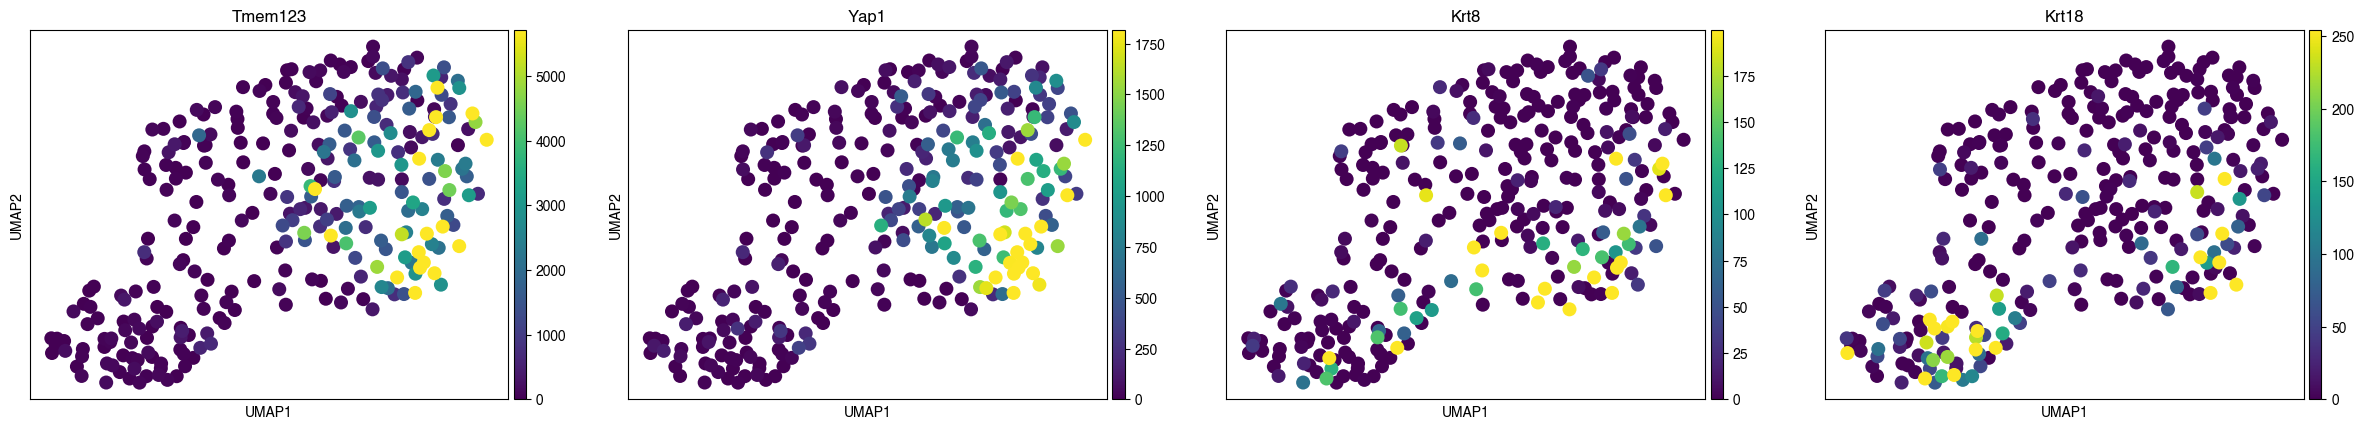

In [15]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata,metric = 'cosine', n_neighbors=50, use_rep='X')
sc.tl.umap(adata, n_components=2, random_state=0)

sc.pl.umap(adata, color=['Tmem123','Yap1', "Krt8", "Krt18"], vmax = 'p95')

['Col1a2', 'Ctla2a', 'Lox', 'Fxyd3', 'Perp', 'Nid1', 'Spint2', 'Krt14', 'Dsc3', 'Sfn']


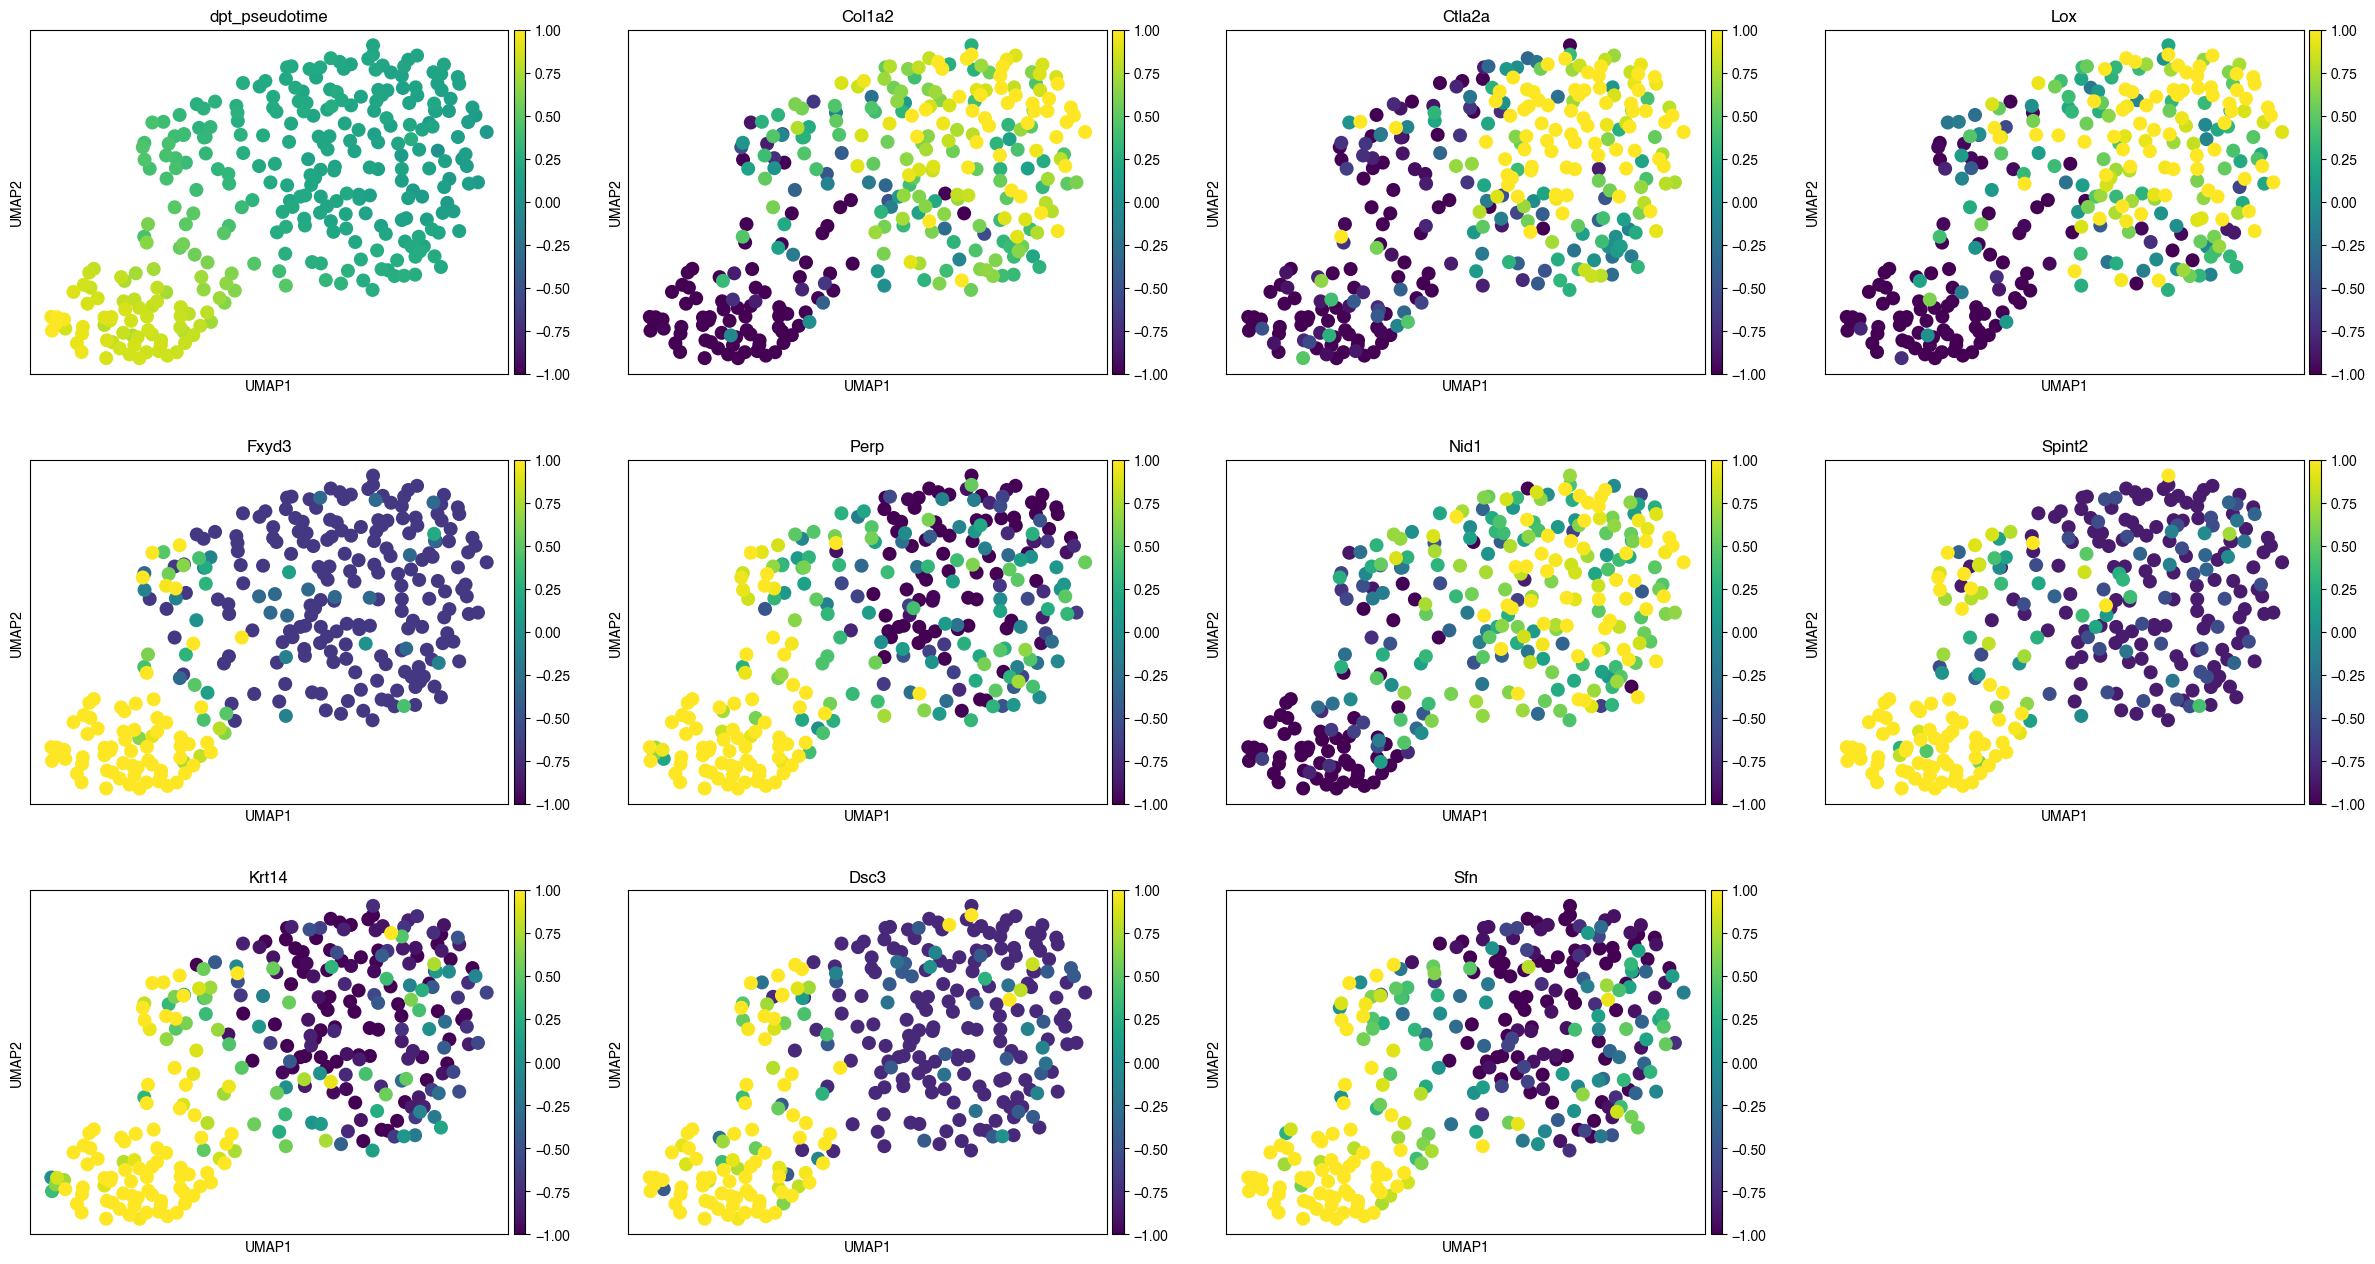

In [ ]:
sc.tl.diffmap(adata, n_comps=10)  # Ensure diffusion map is computed
root_index = np.argmin(adata.obsm['X_diffmap'][:, 0])  # Smallest DC1 value
adata.uns['iroot'] = np.argmin(root_index) # Root cell from original
sc.tl.diffmap(adata, n_comps=50)
sc.tl.dpt(adata, n_dcs=50)

from scipy.stats import spearmanr
import pandas as pd

# Compute Spearman correlation for each gene
gene_corr = {gene: spearmanr(adata[:, gene].X.toarray().flatten(), adata.obs['dpt_pseudotime'])
             for gene in adata.var_names}

# Add per-gene correlation info to adata.var
adata.var['spearman_rho'] = [gene_corr[gene][0] for gene in adata.var_names]
adata.var['spearman_pval'] = [gene_corr[gene][1] for gene in adata.var_names]
adata.var['spearman_rho_weighted'] = [
    gene_corr[gene][0] * (1 - gene_corr[gene][1]) for gene in adata.var_names
]

top10_genes = adata.var['spearman_rho_weighted'].abs().nlargest(10).index.tolist()
print(top10_genes)

sc.pl.umap(adata, color=["dpt_pseudotime"]+top10_genes, use_raw=False, cmap='viridis', vmin=-1, vmax=1)



## Calculate the nonlinearity score for each cell in the EMT dataset

In [ ]:
from rice.models import calculate_sigma
from rice.utils import pearsonr_excluded, spearmanr_binned

## Calculate pseudotime
X = adata.X.copy()

from benchmarks.dataloaders import compute_pseudotime
X, pt_vals, ordering_inds = compute_pseudotime(X, return_ordering=True)
all_sig = calculate_sigma(X, d_embed=10, tol=1e-6, channelwise=True)
all_sig[all_sig == np.min(all_sig)] = np.nan


/Users/william/program_repos/dygene/rice/examples/../../rice/benchmarks/dataloaders.py:395: UserWarning: You’re trying to run this on 1400 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, method='umap')


## Find genes that most strongly correlate with the nonlinearity score

<string>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Cfap300
Stmn2
Msln
Tmem123
Birc2


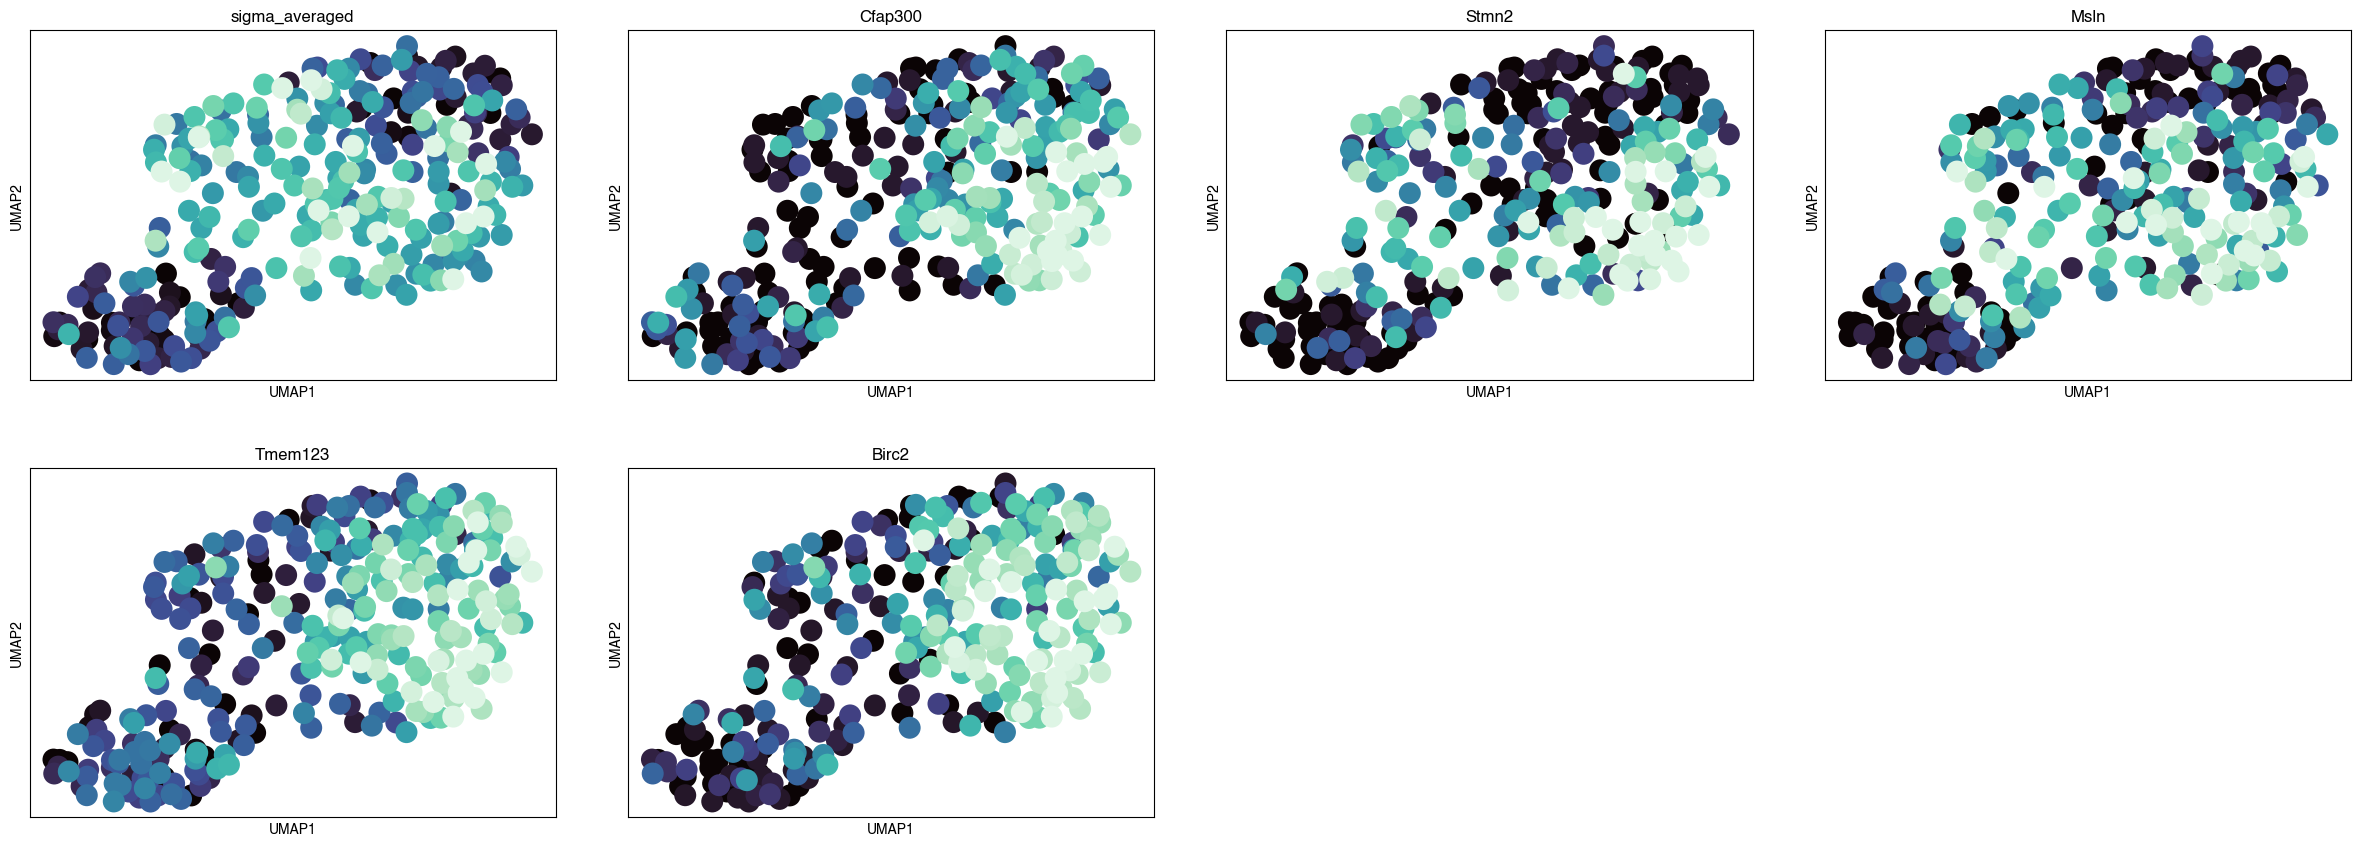

Slc2a1
Lamc2
Tacstd2
Urah
Cstb


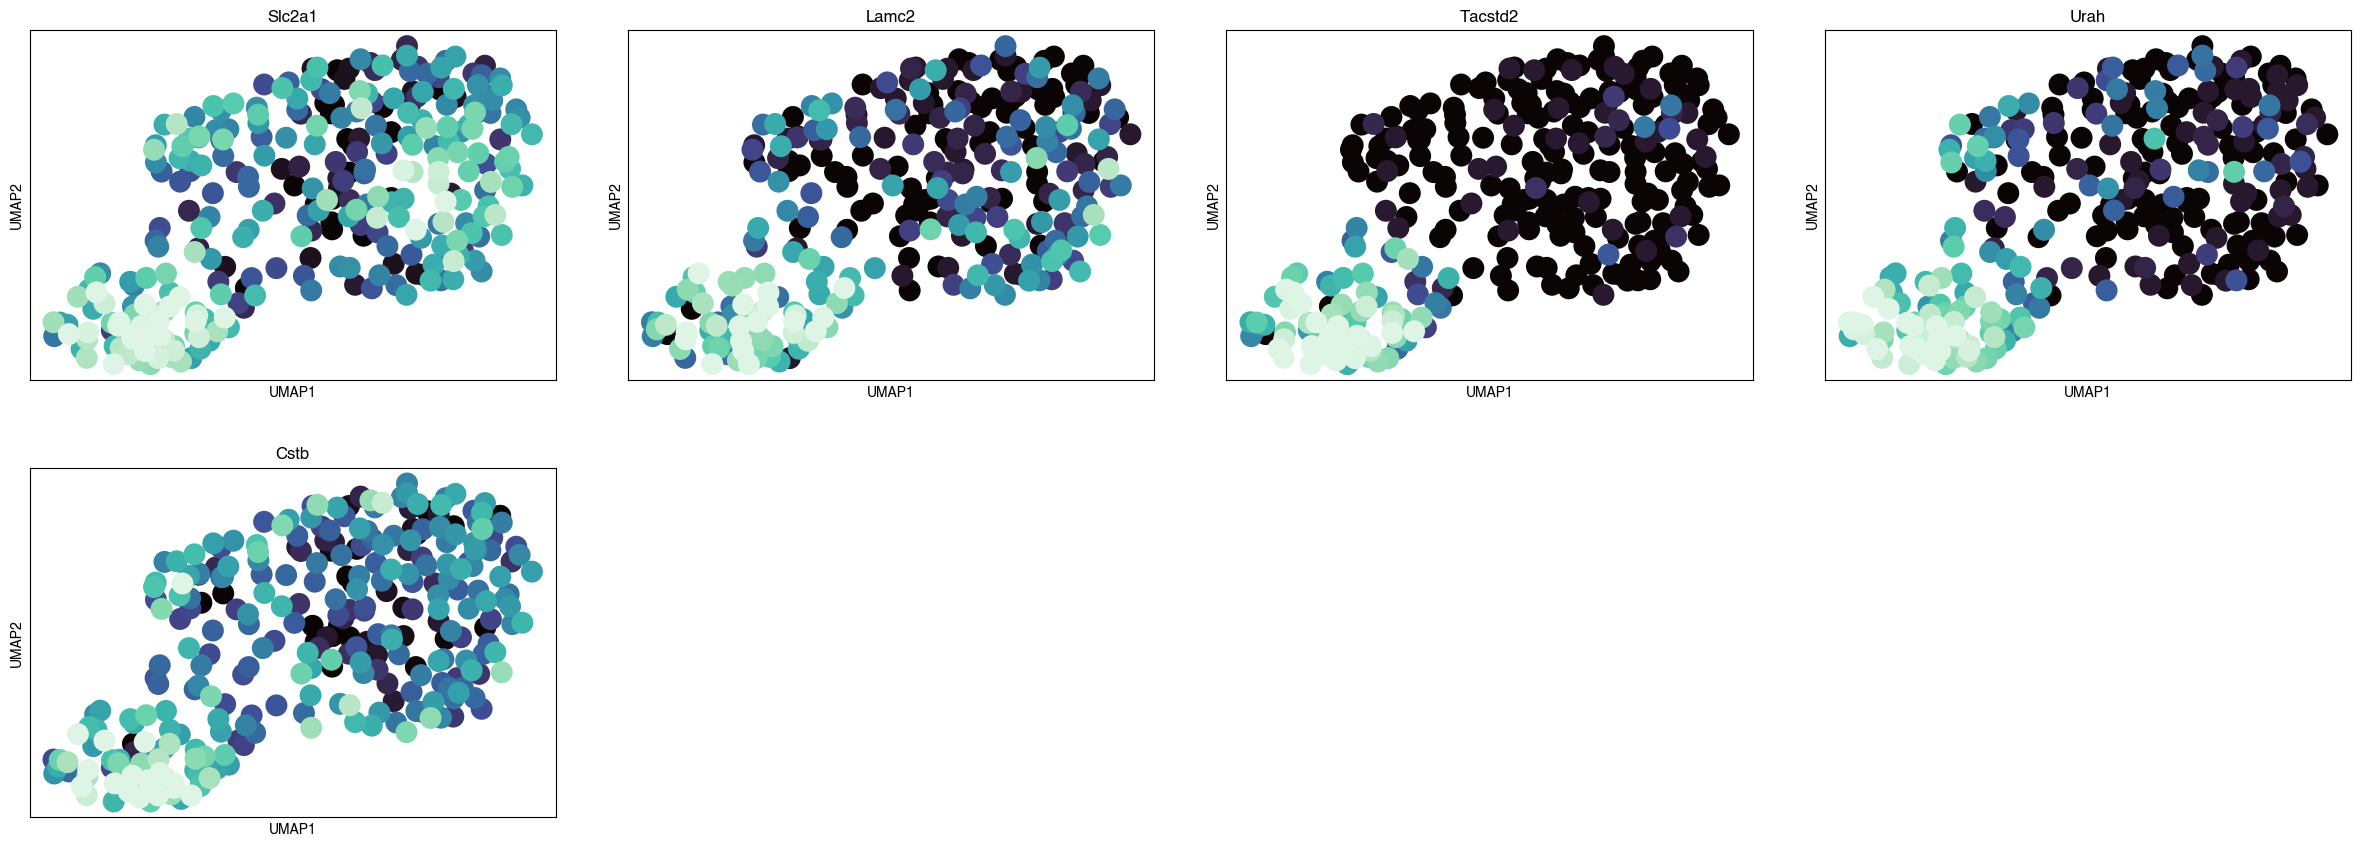

In [27]:
adata.obs['sigma_averaged'] = (1/np.nanmean(all_sig, axis=0)[np.argsort(ordering_inds)])

# Compute Spearman correlation for each gene
# gene_corr = {gene: spearmanr(adata[:, gene].X.toarray().flatten(), 
#                              adata.obs['sigma_averaged'])
#              for gene in adata.var_names}
gene_corr = {gene: spearmanr_binned(adata[:, gene].X.toarray().flatten(), 
                             adata.obs['sigma_averaged'])
             for gene in adata.var_names}

# Add per-gene correlation info to adata.var
adata.var['sigma_rho'] = [gene_corr[gene][0] for gene in adata.var_names]
adata.var['sigma_pval'] = [gene_corr[gene][1] for gene in adata.var_names]
adata.var['sigma_rho_weighted'] = [
    gene_corr[gene][0] * (1 - gene_corr[gene][1]) for gene in adata.var_names
]

top5_genes = adata.var['sigma_rho_weighted'].nlargest(5).index.tolist()
print("\n".join(top5_genes))

sc.pl.umap(adata, color=['sigma_averaged']+top5_genes,
           s=1000,
           use_raw=False, 
           cmap=cmap_mako, 
           vmax = 'p95', vmin = 'p05', colorbar_loc=None)


bottom5_genes = adata.var['sigma_rho_weighted'].nsmallest(5).index.tolist()
print("\n".join(bottom5_genes))


sc.pl.umap(adata, color=bottom5_genes,
           s=1000,
           use_raw=False, 
           cmap=cmap_mako, 
           vmax = 'p95', vmin = 'p05', 
           colorbar_loc=None)



/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_7475/3093277295.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c=adata.obs['sigma_averaged'][plot_order],


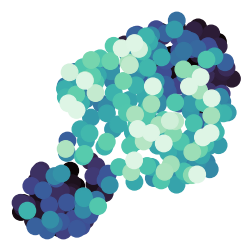

In [30]:
plot_order = np.argsort(adata.obs['sigma_averaged'])
plt.figure(figsize=(3, 3))
plt.scatter(adata.obsm['X_umap'][plot_order, 0], 
            adata.obsm['X_umap'][plot_order, 1], 
            c=adata.obs['sigma_averaged'][plot_order],
            cmap=cmap_mako, s=140, 
            vmin=np.percentile(adata.obs['sigma_averaged'], 5), 
            vmax=np.percentile(adata.obs['sigma_averaged'], 95)
)
plt.grid(False)
dg.vanish_axes()
# fpath = "./hccm/private_writing/fig_resources/emt_det.png"
# dg.better_savefig("./hccm/private_writing/fig_resources/emt_det.png", dpi=300, transparent=True)
# fpath = fpath.replace(".png", ".pdf")
# dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=False)

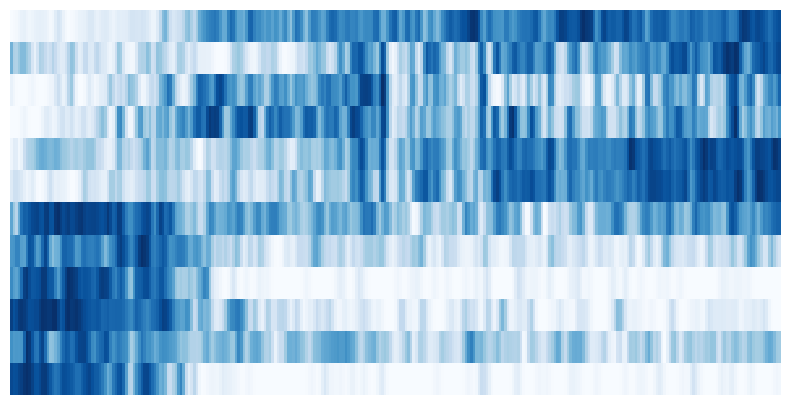

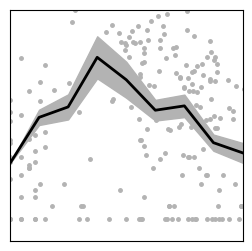

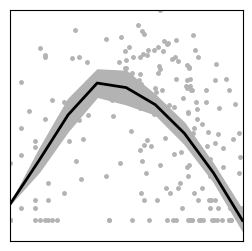

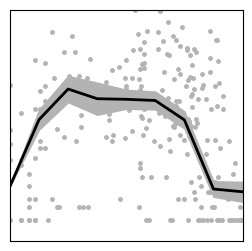

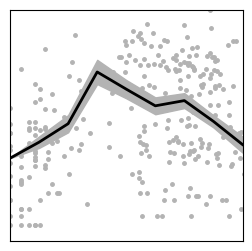

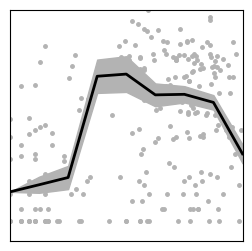

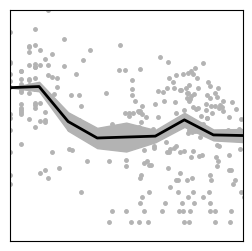

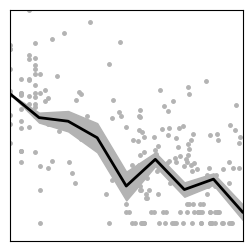

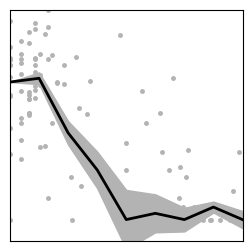

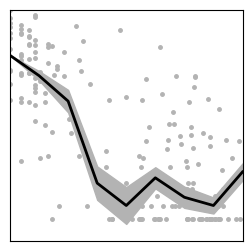

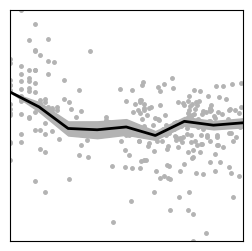

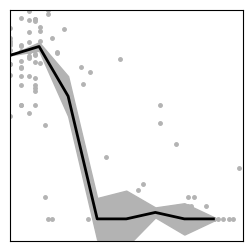

In [ ]:
# X_subset = adata[:, ["Mmp19"] + top5_genes + ["Epcam"]].X
# gene_names_subset = ["Col3a1"] + top5_genes + bottom5_genes + ["Epcam"]
gene_names_subset = ["Col3a1"] + top5_genes + bottom5_genes + ["Epcam"]
X_subset = adata[:, gene_names_subset].X
X_subset_raw = adata.raw[:, gene_names_subset].X
# 'Col1a2',  'Fxyd3'
pt = np.argsort(adata.obs["dpt_pseudotime"])

from rice.utils import binned_statistic_bootstrapped

## Validate direction of pseudotime with pure epithelial marker
marker = np.array(adata[:, "Epcam"].X.squeeze())
corr_dir = spearmanr(adata.obs["dpt_pseudotime"], marker).correlation
if corr_dir > 0:
    adata.obs["dpt_pseudotime"] = -adata.obs["dpt_pseudotime"]
    pt = pt[::-1]

## Sort the cells by pseudotime and then normalize the expression
X_subset = X_subset[pt]
X_subset_raw = X_subset_raw[pt]
X_subset = (X_subset - np.min(X_subset, axis=0)) / (np.max(X_subset, axis=0) - np.min(X_subset, axis=0))
X_subset_std = (X_subset - np.mean(X_subset, axis=0)) / (np.std(X_subset, axis=0) + 1e-6)



from matplotlib import colors as mcolors
cmap_blues = mcolors.LinearSegmentedColormap.from_list("blues", [dg.lighter(dg.blue, 0.5), dg.darker(dg.blue)])
cmap_blues_r = mcolors.LinearSegmentedColormap.from_list("blues_r", [dg.darker(dg.blue), dg.lighter(dg.blue, 0.5)])


DRYRUN = True


## Plot heatmap of expression vs pseudotime
plt.figure(figsize=(10, 5))
# plt.imshow(X_subset.T, interpolation="None", cmap="PuBu", aspect="auto")
sel_inds_cell = np.mean(X_subset_raw > 0, axis=1) > np.percentile(np.mean(X_subset_raw > 0, axis=1), 50)
from scipy.ndimage import gaussian_filter
X_subset_std = gaussian_filter(X_subset_std, sigma=(1, 0.1))
X_subset_std = (X_subset_std - np.min(X_subset_std,axis=0)) / (np.max(X_subset_std, axis=0) - np.min(X_subset_std, axis=0))
plt.imshow(X_subset_std.T, 
           interpolation="None", 
           cmap="Blues",
        #    cmap=sns.color_palette("vlag", as_cmap=True),
        #    cmap=cmap_mako, 
           vmin=0, vmax=1, 
           aspect="auto")
plt.grid(False)
dg.vanish_axes()
# fpath = "./hccm/private_writing/fig_resources/heatmap.png"
# dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=DRYRUN)
# fpath = fpath.replace(".png", ".pdf")
# dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=DRYRUN)

import degas as dg
dg.fixed_aspect_ratio(1/2)

## Iterate over all genes
for condition_ind in range(1, X_subset.shape[1]):

    ## Sort the cells by the first marker gene
    sort_inds = np.argsort(X_subset[:, 0])
    marker_levels = X_subset[sort_inds, 0].copy()
    target_levels = X_subset[sort_inds, condition_ind].copy()

    ## Mask out the cells with zero counts
    mask_levels = X_subset_raw[sort_inds, condition_ind] != 0

    plt.figure(figsize=(3, 3))
    plt.plot(marker_levels[mask_levels], target_levels[mask_levels], '.',
              color=np.ones(3)*0.7, markersize=5)
    bin_edges = np.linspace(marker_levels.min(), marker_levels.max(), 10)
    bin_means, bin_errs, edges, bin_number = binned_statistic_bootstrapped(
        marker_levels[mask_levels], target_levels[mask_levels],
          statistic='median', bins=bin_edges
    )
    dg.plot_err(
        bin_means, bin_errs, edges[:-1], color=np.zeros(3), lightness=0.7, linewidth=2,
    )
    plt.grid(False)
    # plt.ylabel(gene_names_subset[condition_ind])
    plt.xlim([bin_edges[0], bin_edges[-2]])
    plt.ylim([np.min(target_levels), np.max(target_levels)])
    plt.xticks([])
    plt.yticks([])
    plt.gca().set_xticklabels([])
    plt.gca().set_yticklabels([])
    # fpath = f"./hccm/private_writing/fig_resources/heatmap_{gene_names_subset[condition_ind]}.png"
    # dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=DRYRUN)
    # fpath = fpath.replace(".png", ".pdf")
    # dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=DRYRUN)



/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_7475/1856269258.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3, 3))


<Figure size 300x300 with 0 Axes>

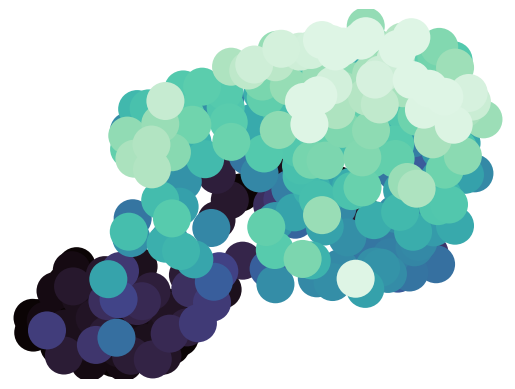

<Figure size 300x300 with 0 Axes>

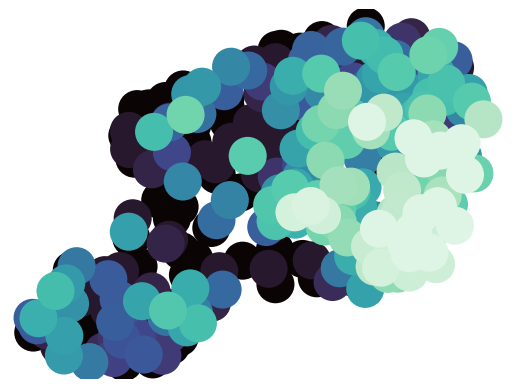

<Figure size 300x300 with 0 Axes>

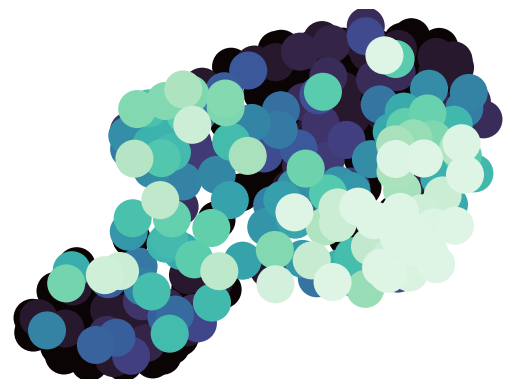

<Figure size 300x300 with 0 Axes>

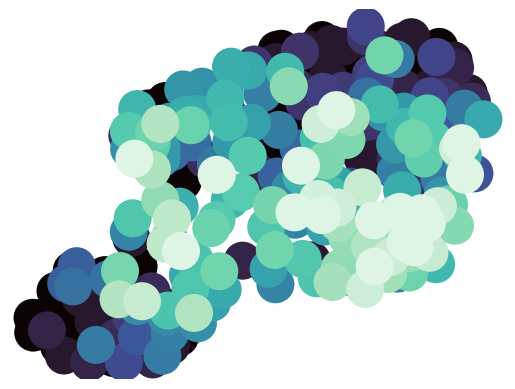

<Figure size 300x300 with 0 Axes>

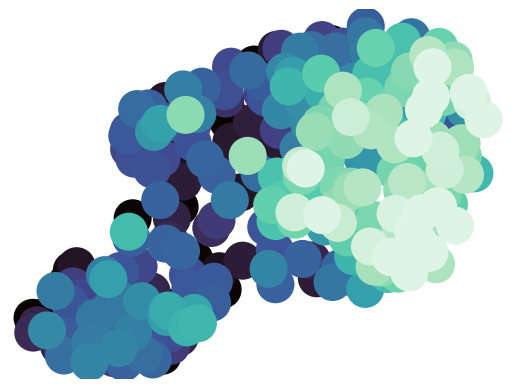

<Figure size 300x300 with 0 Axes>

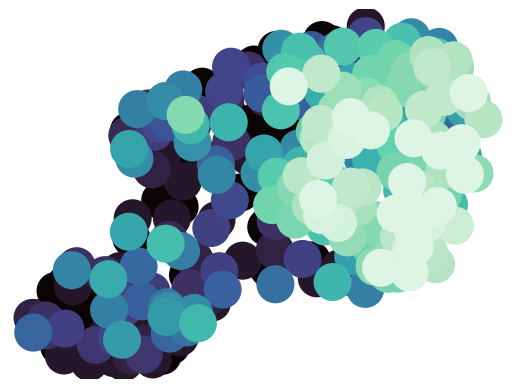

<Figure size 300x300 with 0 Axes>

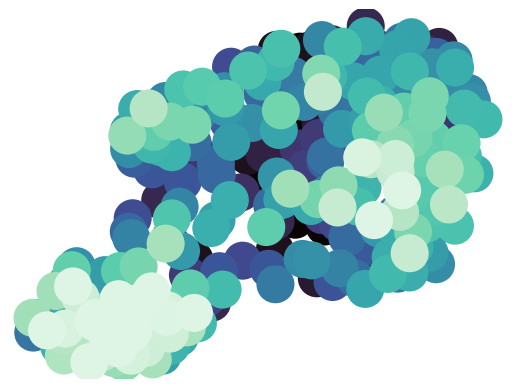

<Figure size 300x300 with 0 Axes>

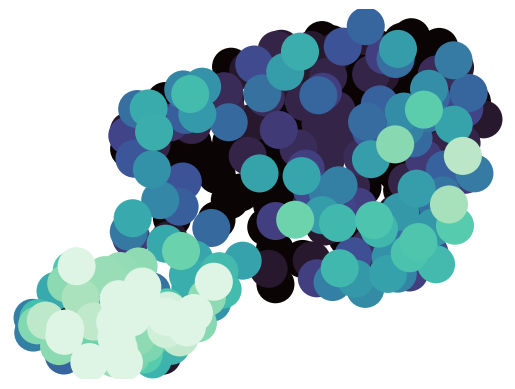

<Figure size 300x300 with 0 Axes>

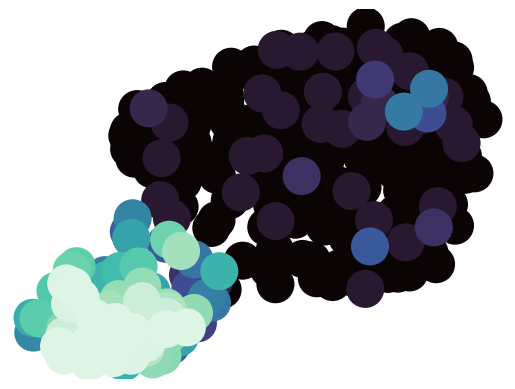

<Figure size 300x300 with 0 Axes>

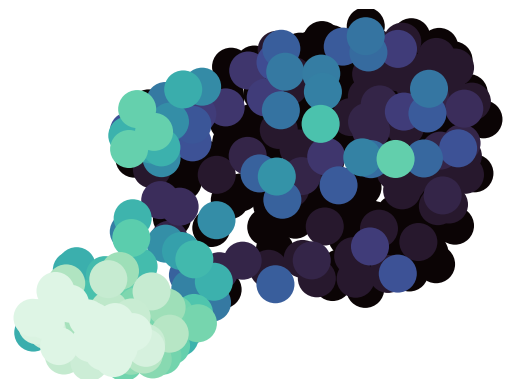

<Figure size 300x300 with 0 Axes>

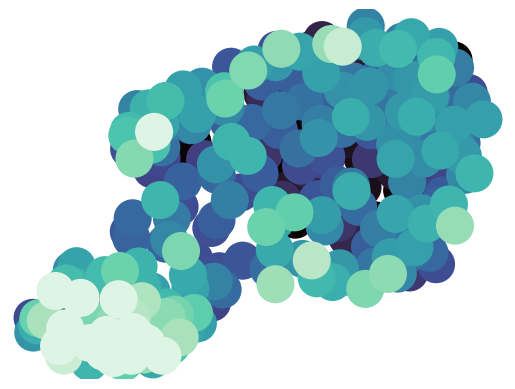

<Figure size 300x300 with 0 Axes>

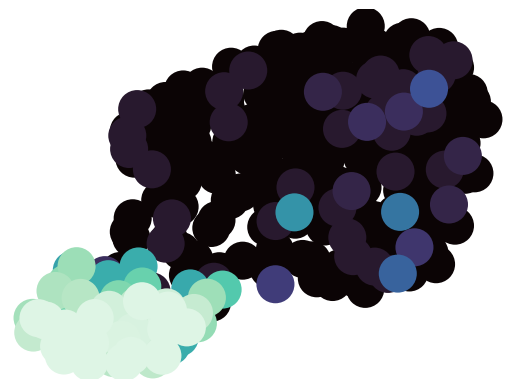

In [35]:
DRYRUN = False
for gene_name in gene_names_subset:
    plt.figure(figsize=(3, 3))
    sc.pl.umap(adata, color=gene_name,
            s=3000,
            use_raw=False, 
            cmap=cmap_mako, 
            title="",
            vmax='p95', vmin='p05', 
            return_fig=True,
            colorbar_loc=None)
    dg.vanish_axes()
#     fpath = f"./hccm/private_writing/fig_resources/umap_{gene_name}.png"
#     dg.better_savefig(fpath, dpi=450, transparent=True, dryrun=DRYRUN)
#     fpath = fpath.replace(".png", ".pdf")
#     dg.better_savefig(fpath, dpi=300, transparent=True, dryrun=DRYRUN)


## Infer interaction network with RiCE

In [ ]:
from rice.models import CausalDetection, calculate_sigma

In [45]:
## Sort cells by pseudotime
tau = adata.obs["dpt_pseudotime"]
sort_inds = np.argsort(tau)
X, tau = X[sort_inds], tau[sort_inds]

## gene names 
gene_names = np.array(adata.var_names)

## Fit the causal detection model to the data
model = CausalDetection(
    d_embed=3, 
    neighbors="simplex", 
    forecast="smap", 
    ensemble=True, 
)
cmat = model.fit(X)

Fitting model with 9 library sizes
[38 25 17 11  7  5  3  2  1]


/var/folders/79/zct6q7kx2yl6b1ryp2rsfbtc0000gr/T/ipykernel_7475/2954760825.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X, tau = X[sort_inds], tau[sort_inds]


/Users/william/program_repos/dygene/rice/examples/../../rice/rice/models.py:496: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(sum_pred2 * var_y)


Large array detected, using temporary memmap
Large array detected, using temporary memmap
Large array detected, using temporary memmap
Large array detected, using temporary memmap
[#################   ] 

Large array detected, using temporary memmap


In [63]:
# cmat = np.load("emt_causal_matrix.pkl", allow_pickle=True)
# gene_names = np.load("emt_gene_names.pkl", allow_pickle=True)
# cmat.dump("emt_causal_matrix.pkl")
# gene_names.dump("emt_gene_names.pkl")

cmat_normalized = np.abs(cmat) / np.max(np.abs(cmat))
outdegree = np.sum(cmat_normalized, axis=0)
rank_out = np.argsort(outdegree)[::-1]

print("Top 30 genes by outdegree:")
for i in range(30):
    print(f"{i+1}. {gene_names[rank_out[i]]}: {outdegree[rank_out[i]]:.4f}")

Top 30 genes by outdegree:
1. Tacstd2: 65.9712
2. Krt17: 60.6227
3. Fxyd3: 60.4509
4. Serpinb5: 59.7605
5. Krt5: 59.7165
6. S100a14: 58.5524
7. Epcam: 56.9561
8. Col1a2: 56.5155
9. Lypd3: 56.2802
10. Dmkn: 55.5777
11. Dsg3: 55.0514
12. Col1a1: 55.0337
13. Lamb3: 54.5741
14. Cdh1: 52.5765
15. Krt6a: 51.9710
16. Spint2: 51.0512
17. Col5a2: 49.6070
18. Urah: 49.5575
19. Serinc2: 49.0202
20. Tns4: 48.6585
21. Col3a1: 48.5593
22. Dsc3: 48.0974
23. Cdcp1: 47.9480
24. Col17a1: 47.4311
25. Aqp3: 47.3161
26. Krt14: 46.6013
27. Dsp: 46.1149
28. Sfn: 45.2827
29. Krtdap: 45.0694
30. Bcam: 44.3208
